# Visualizing decision boundaries
If the problem is simple enough (e.g., 2D input space), we can visualize the decision boundaries of a classifier. This is useful to understand how the model works and to identify potential issues such as overfitting or underfitting.

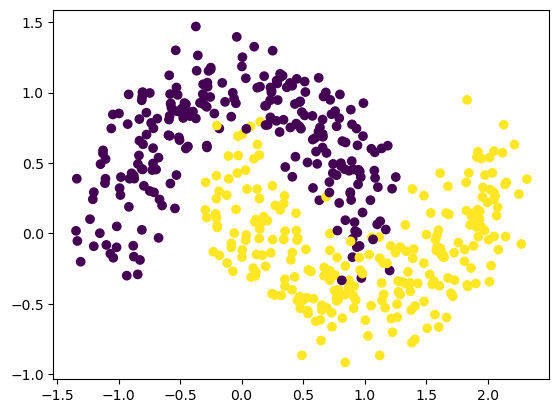

In [50]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
import numpy as np

X,y = make_moons(
    n_samples=500,
    shuffle=True,
    noise=0.2
)

plt.scatter(X[:,0], X[:,1], c=y)

What we need now is the following:
- a grid of points
- a function to train an arbitrary classifier, evaluate it on the grid and plot the results

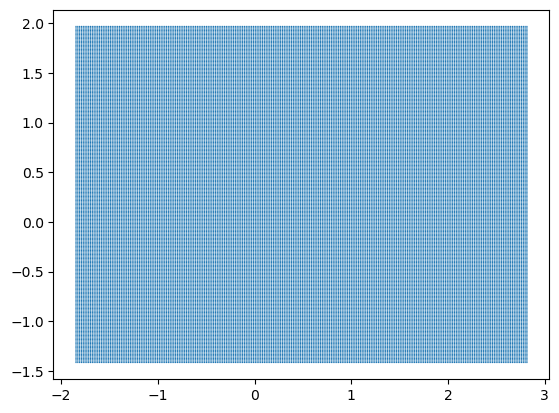

In [ ]:
# Choose a resolution – higher = smoother but slower
grid_size = 250

# Compute min/max of each dimension (with a small margin)
x_min, x_max = 0,1
y_min, y_max = 0,1

# Create meshgrid using np.meshgrid function (use linspace to create vectors)
xx, yy = np.meshgrid(...)

# Create a matrix of grid points "similar to the data" by stacking the flattened outputs of meshgrid
grid_points =...

plt.scatter(grid_points[:,0], grid_points[:,1], s=1, edgecolor="none")

Now, a function that:
- takes as an argument an unfitted classifier, some data, the grid and a string with the name of the classifier
- fits the classifier on the data
- evalautes the classifier on the grid
- plots everything

In [84]:
def decision_boundary(clf, X,y,name="Classifier"):
    clf.fit(X,y)
    preds = clf.predict(grid_points)
    probas = clf.predict_proba(grid_points)[:,1]
    fig = plt.figure(figsize=(12,6))

    ax = fig.add_subplot(121)
    contour = ax.contourf(xx,yy,preds.reshape(xx.shape))
    plt.colorbar(contour)
    ax.scatter(X[:,0], X[:,1], c=y, edgecolor='k')
    ax.set_title(f"{name} - Labels")
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")

    ax = fig.add_subplot(122)
    contour = ax.contourf(xx,yy,probas.reshape(xx.shape))
    plt.colorbar(contour)
    ax.scatter(X[:,0], X[:,1], c=y, edgecolor='k')
    ax.set_title(f"{name} - Probabilities")
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")

    plt.tight_layout()
    plt.show()
    return None

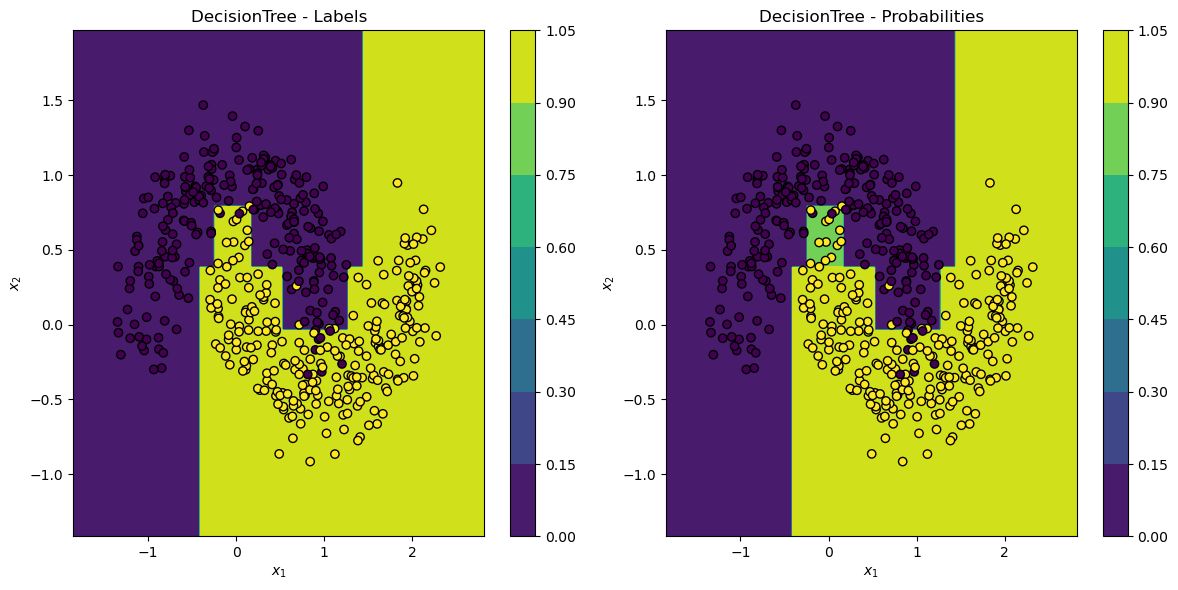

In [108]:
from sklearn.tree import DecisionTreeClassifier

decision_boundary(
    DecisionTreeClassifier(max_depth=5),
    X,y,"DecisionTree"
)

now, apply the function as described above for other models... :)